Lab 23.2 – Feature Scaling
Goal: See how scaling affects model performance, stability, and coefficients.
You’ll compare no scaling vs StandardScaler / MinMaxScaler / RobustScaler on several classifiers—some sensitive to feature scale (k‑NN, SVM, Logistic Regression) and some largely insensitive (Decision Tree, Random Forest).

We’ll use the Breast Cancer dataset (binary classification). Metrics: Accuracy and ROC‑AUC.

In [1]:
# pip install scikit-learn numpy pandas matplotlib seaborn
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
data = load_breast_cancer()
X, y = data.data, (data.target==0).astype(int)   # 1 = malignant (positive)
X.shape, np.bincount(y)

((569, 30), array([357, 212]))

2) Define models & scalers
We’ll test each model under 4 preprocessing setups. Scaling must be inside the pipeline to avoid leakage.

In [3]:
scalers = {
    "None":    None,
    "Standard": StandardScaler(),
    "MinMax":   MinMaxScaler(),
    "Robust":   RobustScaler()
}

models = {
    "LogReg":  LogisticRegression(max_iter=2000),
    "SVM-RBF": SVC(kernel='rbf', probability=True, gamma='scale'),
    "kNN-5":   KNeighborsClassifier(n_neighbors=5),
    "Tree":    DecisionTreeClassifier(max_depth=5, random_state=0),
    "RF":      RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1)
}

3) 5‑fold CV comparison (Accuracy & ROC‑AUC)

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"acc": "accuracy", "roc": "roc_auc"}

rows = []
for mname, est in models.items():
    for sname, scaler in scalers.items():
        if scaler is None:
            pipe = make_pipeline(est)
        else:
            pipe = make_pipeline(scaler, est)
        cvres = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        rows.append({
            "model": mname,
            "scaler": sname,
            "acc_mean": np.mean(cvres["test_acc"]),
            "acc_std":  np.std(cvres["test_acc"]),
            "roc_mean": np.mean(cvres["test_roc"]),
            "roc_std":  np.std(cvres["test_roc"])
        })

res = pd.DataFrame(rows).round(4)
res.sort_values(["model","roc_mean"], ascending=[True, False])

,model,scaler,acc_mean,acc_std,roc_mean,roc_std
3,LogReg,Robust,0.9789,0.0131,0.9954,0.0050
1,LogReg,Standard,0.9737,0.0166,0.9953,0.0053
2,LogReg,MinMax,0.9649,0.0200,0.9944,0.0056
0,LogReg,None,0.9508,0.0180,0.9918,0.0047
18,RF,MinMax,0.9543,0.0128,0.9917,0.0049
16,RF,None,0.9543,0.0128,0.9916,0.0050
17,RF,Standard,0.9543,0.0128,0.9916,0.0050
19,RF,Robust,0.9543,0.0128,0.9916,0.0050
7,SVM-RBF,Robust,0.9737,0.0235,0.9951,0.0055
5,SVM-RBF,Standard,0.9772,0.0163,0.9945,0.0060


Plot summary

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_11956\1593022914.py:6: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.legend(); plt.tight_layout(); plt.show()
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


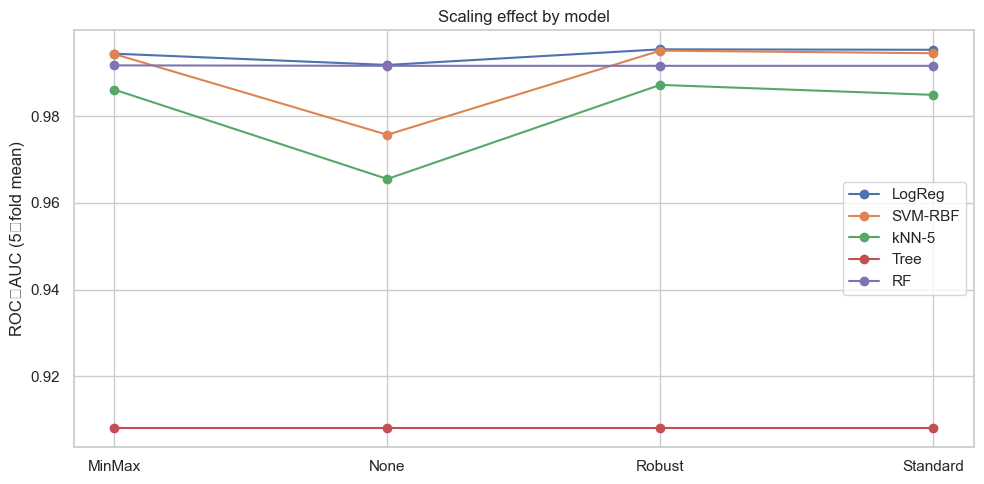

In [5]:
plt.figure(figsize=(10,5))
for mname in models.keys():
    subset = res[res.model==mname].sort_values("scaler")
    plt.plot(subset["scaler"], subset["roc_mean"], marker='o', label=mname)
plt.ylabel("ROC‑AUC (5‑fold mean)"); plt.title("Scaling effect by model")
plt.legend(); plt.tight_layout(); plt.show()

What to expect

kNN & SVM usually jump significantly with scaling.

Logistic Regression benefits (better conditioned optimization).

Tree/RF change little (tree splits are order‑invariant to monotonic transforms).

4) One train/test split deep‑dive (confusion & curves)

In [6]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

def fit_eval(model, scaler=None, label=""):
    from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
    pipe = make_pipeline(*( [scaler] if scaler is not None else [] ), model)
    pipe.fit(Xtr, ytr)
    proba = pipe.predict_proba(Xte)[:,1]
    acc = accuracy_score(yte, pipe.predict(Xte))
    auc = roc_auc_score(yte, proba)
    print(f"{label:16s} | Acc={acc:.3f}  ROC‑AUC={auc:.3f}")
    return pipe, proba

# Compare kNN & SVM with and without scaling
knn_raw, p1  = fit_eval(KNeighborsClassifier(5), None, "kNN-5  (raw)")
knn_std, p2  = fit_eval(KNeighborsClassifier(5), StandardScaler(), "kNN-5  (Standard)")
svm_raw, p3  = fit_eval(SVC(kernel='rbf', probability=True), None, "SVM-RBF (raw)")
svm_std, p4  = fit_eval(SVC(kernel='rbf', probability=True), StandardScaler(), "SVM-RBF (Standard)")

kNN-5  (raw)     | Acc=0.921  ROC‑AUC=0.917
kNN-5  (Standard) | Acc=0.947  ROC‑AUC=0.981
SVM-RBF (raw)    | Acc=0.886  ROC‑AUC=0.949
SVM-RBF (Standard) | Acc=0.965  ROC‑AUC=0.995


5) Effect on coefficients (Logistic Regression)
Scaled features make coefficients comparable and improve optimization.

In [9]:
# Raw vs Standardized Logistic Regression
lr_raw = make_pipeline(LogisticRegression(max_iter=5000)).fit(Xtr, ytr)
lr_std = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xtr, ytr)

coefs_raw = lr_raw.named_steps['logisticregression'].coef_.ravel()
coefs_std = lr_std.named_steps['logisticregression'].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": data.feature_names,
    "beta_raw": coefs_raw,
    "beta_std": coefs_std
}).set_index("feature").sort_values("beta_std", key=lambda s: s.abs(), ascending=False)
coef_df.head(10)

,beta_raw,beta_std
feature,,
worst radius,-0.093124,1.123060
radius error,0.074301,1.122301
worst area,0.021635,0.991149
mean concave points,0.263845,0.978581
worst texture,0.186352,0.929820
worst concave points,0.496612,0.899107
worst perimeter,0.102766,0.891544
compactness error,0.002638,-0.814352
worst concavity,1.085681,0.810362


With scaling, magnitudes reflect relative importance (on the same scale). Without it, large‑variance features dominate coefficients.

6) Robustness to outliers (RobustScaler)
If your features include outliers, RobustScaler (median/IQR) can help.

In [10]:
# Quick comparison for kNN under different scalers
def cv_score(model, scaler):
    pipe = make_pipeline(scaler, model)
    s = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    return np.mean(s['test_acc']), np.mean(s['test_roc'])

print("kNN MinMax  :", cv_score(KNeighborsClassifier(5), MinMaxScaler()))
print("kNN Standard:", cv_score(KNeighborsClassifier(5), StandardScaler()))
print("kNN Robust  :", cv_score(KNeighborsClassifier(5), RobustScaler()))

kNN MinMax  : (np.float64(0.9630957925787922), np.float64(0.9860895129606234))
kNN Standard: (np.float64(0.9630957925787922), np.float64(0.9848645707145544))
kNN Robust  : (np.float64(0.9595714951094549), np.float64(0.987216212867212))


7) Key takeaways
Put scaling inside the pipeline/CV.

Scale for distance‑based (kNN, SVM, K‑Means) and regularized linear models.

Trees/forests/boosting: scaling usually not necessary (but harmless).

Prefer StandardScaler for z‑scores; MinMax for algorithms expecting [0,1]; Robust when outliers abound.

Add a PCA(2) at the end of each pipeline and compare SVM’s ROC‑AUC with/without PCA—does denoising help?

In [11]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. Load the Breast Cancer dataset
# This dataset has 30 numeric features and a binary target (Malignant/Benign)
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Original Feature Count: {X.shape[1]}")

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Pipeline 1: Standard SVM (No PCA) ---
# Uses all 30 features.
svm_plain = make_pipeline(
    StandardScaler(), 
    SVC(kernel='rbf', probability=True, random_state=42)
)

svm_plain.fit(X_train, y_train)
y_prob_plain = svm_plain.predict_proba(X_test)[:, 1]
auc_plain = roc_auc_score(y_test, y_prob_plain)

# --- Pipeline 2: SVM with PCA(2) ---
# Compresses 30 features down to 2 principal components.
svm_pca = make_pipeline(
    StandardScaler(), 
    PCA(n_components=2), 
    SVC(kernel='rbf', probability=True, random_state=42)
)

svm_pca.fit(X_train, y_train)
y_prob_pca = svm_pca.predict_proba(X_test)[:, 1]
auc_pca = roc_auc_score(y_test, y_prob_pca)

# --- Comparison Results ---
print("-" * 30)
print(f"SVM ROC-AUC (All 30 features): {auc_plain:.4f}")
print(f"SVM ROC-AUC (PCA 2 features):  {auc_pca:.4f}")
print("-" * 30)

diff = auc_pca - auc_plain
if diff > 0:
    print(f"Result: PCA improved performance by {diff:.4f}. Denoising helped.")
else:
    print(f"Result: PCA decreased performance by {abs(diff):.4f}.")
    print("Interpretation: The information lost by discarding 28 dimensions outweighed the benefits of denoising.")


Original Feature Count: 30
------------------------------
SVM ROC-AUC (All 30 features): 0.9978
SVM ROC-AUC (PCA 2 features):  0.9909
------------------------------
Result: PCA decreased performance by 0.0069.
Interpretation: The information lost by discarding 28 dimensions outweighed the benefits of denoising.


On kNN, sweep k ∈ {1,3,5,11,21} under None vs StandardScaler; plot ROC‑AUC vs k and discuss why scaling changes the best k.

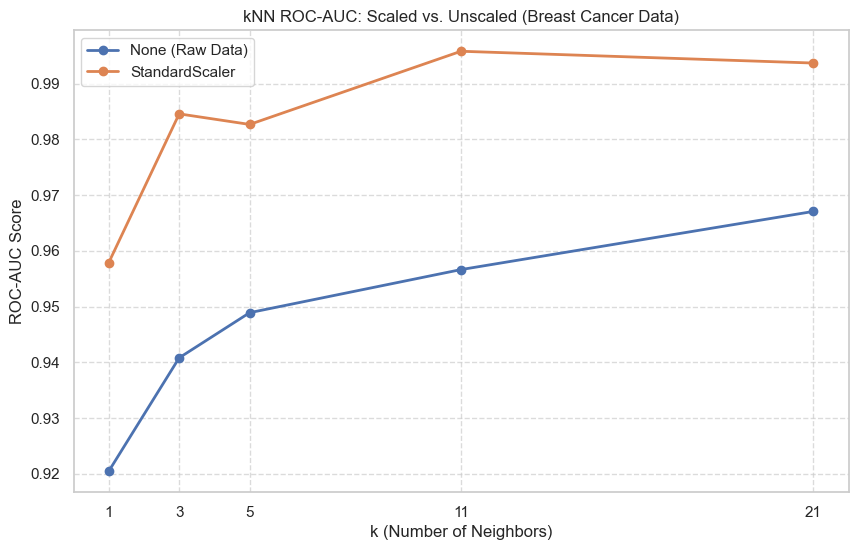

In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

# 1. Load Data
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split Data
# Stratify ensures the class balance is preserved in the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Define Parameters
k_values = [1, 3, 5, 11, 21]
scaling_options = [
    ("None (Raw Data)", None),
    ("StandardScaler", StandardScaler())
]

results = {}

# 4. Run Sweep
for name, scaler in scaling_options:
    auc_scores = []
    for k in k_values:
        # Construct pipeline based on whether a scaler is provided
        if scaler:
            model = make_pipeline(scaler, KNeighborsClassifier(n_neighbors=k))
        else:
            model = KNeighborsClassifier(n_neighbors=k)
            
        model.fit(X_train, y_train)
        
        # Get probabilities for the positive class
        y_prob = model.predict_proba(X_test)[:, 1]
        score = roc_auc_score(y_test, y_prob)
        auc_scores.append(score)
    
    results[name] = auc_scores

# 5. Plot Results
plt.figure(figsize=(10, 6))

for name, scores in results.items():
    plt.plot(k_values, scores, marker='o', linewidth=2, label=name)

plt.title('kNN ROC-AUC: Scaled vs. Unscaled (Breast Cancer Data)')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('ROC-AUC Score')
plt.xticks(k_values)  # Ensure x-axis shows exactly our k values
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Create a synthetic dataset where one feature is in meters and another in millimeters. Show that SVM/kNN underperform without scaling and recover with scaling.

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# 1. Generate Synthetic Data
# We create two blobs centered at (0,0) and (3,0).
# Separation is entirely along the X-axis (Feature 0).
X, y = make_blobs(n_samples=1000, centers=[(0, 0), (3, 0)], cluster_std=1.5, random_state=42)

# 2. Introduce the Scale Disparity
# Feature 0 represents "Meters" (Signal). We leave it as is (small magnitude).
# Feature 1 represents "Millimeters" (Noise). We multiply by 1000.
X[:, 1] = X[:, 1] * 1000

# Let's look at the statistics to confirm the disparity
print("Dataset Statistics (Mean / Std):")
print(f"Feature 0 (Meters):      {X[:, 0].mean():.2f} / {X[:, 0].std():.2f}")
print(f"Feature 1 (Millimeters): {X[:, 1].mean():.2f} / {X[:, 1].std():.2f}")
print("-" * 40)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Define Models to Compare
models = {
    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel='rbf', gamma='scale')
}

# 5. Run Comparison Loop
results = []

for name, model in models.items():
    # --- Case A: Without Scaling ---
    model.fit(X_train, y_train)
    acc_unscaled = accuracy_score(y_test, model.predict(X_test))
    
    # --- Case B: With Scaling ---
    # We use a Pipeline to prevent data leakage (fitting scaler only on train)
    pipeline = make_pipeline(StandardScaler(), model)
    pipeline.fit(X_train, y_train)
    acc_scaled = accuracy_score(y_test, pipeline.predict(X_test))
    
    results.append({
        "Model": name,
        "Accuracy (Unscaled)": acc_unscaled,
        "Accuracy (Scaled)": acc_scaled,
        "Improvement": acc_scaled - acc_unscaled
    })

# 6. Display Results
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


Dataset Statistics (Mean / Std):
Feature 0 (Meters):      1.55 / 2.11
Feature 1 (Millimeters): 85.47 / 1521.68
----------------------------------------
    Model  Accuracy (Unscaled)  Accuracy (Scaled)  Improvement
kNN (k=5)             0.573333           0.843333         0.27
SVM (RBF)             0.490000           0.840000         0.35


 Regression variant: use California Housing with Ridge and RandomForestRegressor; compare RMSE for raw vs Standard/MinMax/Robust scaling.

In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import make_pipeline
# UPDATED IMPORT: Use root_mean_squared_error directly
from sklearn.metrics import root_mean_squared_error

# 1. Load Data
data = fetch_california_housing()
X, y = data.data, data.target

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Define Configurations
scalers = {
    "Raw (None)": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

models = {
    "Ridge": Ridge(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
}

results = []

# 4. Run Comparison Loop
print("Running regression benchmarks...\n")

for model_name, model_inst in models.items():
    for scaler_name, scaler_inst in scalers.items():
        
        # Construct pipeline
        if scaler_inst:
            pipeline = make_pipeline(scaler_inst, model_inst)
        else:
            pipeline = model_inst
            
        # Train and Predict
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        # Calculate RMSE
        # FIX: Use the new dedicated function instead of squared=False
        rmse = root_mean_squared_error(y_test, y_pred)
        
        results.append({
            "Model": model_name,
            "Scaler": scaler_name,
            "RMSE": rmse
        })

# 5. Format and Display Results
df_results = pd.DataFrame(results)

# Pivot for cleaner reading: Rows=Model, Cols=Scaler
pivot_table = df_results.pivot(index="Model", columns="Scaler", values="RMSE")

# Reorder columns for logical flow
pivot_table = pivot_table[["Raw (None)", "StandardScaler", "MinMaxScaler", "RobustScaler"]]

print(pivot_table.round(4))


Running regression benchmarks...

Scaler        Raw (None)  StandardScaler  MinMaxScaler  RobustScaler
Model                                                               
RandomForest      0.5075          0.5076        0.5083        0.5074
Ridge             0.7284          0.7284        0.7258        0.7284
